# 🌫️ PM2.5 — Weather Forecast Features + Retrain

## Objectif
Ajouter les **prévisions météo futures** comme features pour améliorer H+6 → H+24.

| Étape | Contenu |
|-------|---------|
| 1 | Collecter les prévisions météo (OpenWeatherMap forecast API) |
| 2 | Construire les features météo futures pour chaque horizon |
| 3 | Enrichir le dataset existant |
| 4 | Retrain Direct LGB + CB avec nouvelles features |
| 5 | Comparer avant / après sur H+1 → H+24 |
| 6 | Analyse de l'importance des nouvelles features |
| 7 | Sauvegarde modèles finaux |

**Hypothèse :** La météo future (vent, température, humidité) explique une grande
partie des variations PM2.5 aux horizons longs. En donnant au modèle ce qu'il fera
dans 6h/12h/24h, il peut anticiper la dispersion ou accumulation de particules.

## 0. Configuration

In [21]:
# !pip install requests tqdm lightgbm catboost optuna joblib pyarrow

import warnings, gc, joblib, json, time
from pathlib import Path
import requests
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor, Pool
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths ──────────────────────────────────────────────────────────────────────
FE_DIR       = Path(r'E:\pipeline\test2\feature_engineering_outputs')
ENSEMBLE_DIR = Path(r'E:\pipeline\test2\ensemble_outputs')
WEATHER_DIR  = Path(r'E:\pipeline\test2\weather_forecast_cache')
OUT_DIR      = Path(r'E:\pipeline\test2\weather_model_outputs')
WEATHER_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── OpenWeatherMap API ─────────────────────────────────────────────────────────
# Clé gratuite sur https://openweathermap.org/api — 1000 appels/jour
OWM_API_KEY = '209613b16c3a6c2059e88ff2b09bdc81'   # ← remplacer

# ── Constantes ─────────────────────────────────────────────────────────────────
HORIZONS    = list(range(1, 25))
TARGET_COLS = [f'target24_h{h}' for h in HORIZONS]
TARGET_H1   = 'target24_h1'
SEED        = 42

# Horizons météo à prévoir (sous-ensemble pour limiter les appels API)
WEATHER_HORIZONS = [1, 2, 3, 6, 9, 12, 15, 18, 21, 24]

np.random.seed(SEED)
print('✅ Config OK')

✅ Config OK


## 1. Collecte des Prévisions Météo

### Option A : API temps réel (pour la production)
### Option B : Reconstruction depuis les données historiques (pour l'entraînement)

In [22]:
# ── Coordonnées des 50 villes marocaines ─────────────────────────────────────
CITY_COORDS = {
    'Agadir':              (30.4202, -9.5982),
    'Ait Melloul':         (30.3337, -9.4997),
    'Al Fqih Ben Çalah':   (32.5008, -6.6998),
    'Al Hoceïma':          (35.2517, -3.9372),
    'Ben Guerir':          (32.2333, -7.9500),
    'Beni Mellal':         (32.3373, -6.3498),
    'Berkane':             (34.9200, -2.3200),
    'Berrechid':           (33.2667, -7.5833),
    'Bouskoura':           (33.4500, -7.6667),
    'Casablanca':          (33.5731, -7.5898),
    'Dar Bouazza':         (33.5167, -7.7500),
    'El Jadida':           (33.2549, -8.5079),
    'El Kelaa des Srarhna':(32.0500, -7.4167),
    'Errachidia':          (31.9314, -4.4244),
    'Essaouira':           (31.5125, -9.7700),
    'Fes':                 (34.0372, -5.0000),
    'Fnidek':              (35.8484, -5.3597),
    'Guelmim':             (28.9873, -10.0574),
    'Guercif':             (34.2333, -3.3500),
    'Inezgane':            (30.3569, -9.5360),
    'Kenitra':             (34.2610, -6.5802),
    'Khemisset':           (33.8167, -6.0667),
    'Khenifra':            (32.9333, -5.6667),
    'Khouribga':           (32.8833, -6.9167),
    'Ksar El Kebir':       (34.9997, -5.9000),
    'Larache':             (35.1932, -6.1556),
    'Lqoliaa':             (30.3833, -9.5333),
    'Marrakesh':           (31.6295, -7.9811),
    'Meknes':              (33.8833, -5.5500),
    'Mohammedia':          (33.6861, -7.3833),
    'Nador':               (35.1686, -2.9335),
    'Oued Zem':            (32.8667, -6.5667),
    'Ouislane':            (33.9167, -5.4833),
    'Oujda':               (34.6814, -1.9086),
    'Oulad Teïma':         (30.4000, -9.2000),
    'Rabat':               (33.9716, -6.8498),
    'Safi':                (32.2994, -9.2372),
    'Sale':                (34.0333, -6.8000),
    'Salé Al Jadida':      (34.0500, -6.7833),
    'Sefrou':              (33.8300, -4.8333),
    'Settat':              (33.0000, -7.6167),
    'Sidi Kacem':          (34.2167, -5.7000),
    'Sidi Slimane':        (34.2667, -5.9333),
    'Tangier':             (35.7595, -5.8340),
    'Taourirt':            (34.4119, -2.8956),
    'Taroudant':           (30.4667, -8.8667),
    'Taza':                (34.2100, -4.0100),
    'Temara':              (33.9333, -6.9167),
    'Tiflet':              (33.8944, -6.3064),
    'Tétouan':             (35.5785, -5.3684),
}
print(f'✅ {len(CITY_COORDS)} villes configurées')

✅ 50 villes configurées


In [23]:
# ── Option A : Appel API OWM (production / données récentes) ──────────────────
def fetch_owm_forecast(city: str, lat: float, lon: float,
                       api_key: str, cache_dir: Path) -> pd.DataFrame:
    """
    Récupère les prévisions météo 5 jours / 3h depuis OpenWeatherMap.
    Met en cache localement pour éviter de répéter les appels.
    """
    cache_file = cache_dir / f'{city.replace(" ", "_")}_{pd.Timestamp.now().strftime("%Y%m%d_%H")}.parquet'
    
    if cache_file.exists():
        return pd.read_parquet(cache_file)
    
    url = (
        f'https://api.openweathermap.org/data/2.5/forecast'
        f'?lat={lat}&lon={lon}&appid={api_key}&units=metric'
    )
    resp = requests.get(url, timeout=10)
    resp.raise_for_status()
    data = resp.json()
    
    rows = []
    for item in data['list']:
        rows.append({
            'datetime':        pd.to_datetime(item['dt'], unit='s'),
            'city':            city,
            'temp_fc':         item['main']['temp'],
            'humidity_fc':     item['main']['humidity'],
            'pressure_fc':     item['main']['pressure'],
            'wind_speed_fc':   item['wind']['speed'],
            'wind_deg_fc':     item['wind'].get('deg', 0),
            'clouds_fc':       item['clouds']['all'],
            'weather_main_fc': item['weather'][0]['main'],
            'pop_fc':          item.get('pop', 0),   # probabilité de précipitation
        })
    
    df_fc = pd.DataFrame(rows)
    df_fc.to_parquet(cache_file, index=False)
    return df_fc


def fetch_all_cities_forecast(city_coords: dict, api_key: str,
                               cache_dir: Path) -> pd.DataFrame:
    """Récupère les prévisions pour toutes les villes."""
    dfs = []
    for city, (lat, lon) in tqdm(city_coords.items(), desc='Fetching forecasts'):
        try:
            df_fc = fetch_owm_forecast(city, lat, lon, api_key, cache_dir)
            dfs.append(df_fc)
            time.sleep(0.1)  # respecter le rate limit
        except Exception as e:
            print(f'  ⚠️  {city}: {e}')
    return pd.concat(dfs, ignore_index=True)


# ── Option B : Simuler les features météo futures depuis l'historique ──────────
# (Pour l'entraînement — on utilise les vraies valeurs futures comme proxy
#  des prévisions météo, ce qui est une upper bound du gain possible)
def build_future_weather_features(df: pd.DataFrame,
                                   weather_horizons: list) -> pd.DataFrame:
    """
    Construit les features météo futures en utilisant les vraies valeurs.
    En production, ces valeurs viendraient de l'API OWM.
    
    Pour chaque horizon h dans weather_horizons, on ajoute :
    - temp_fc_h, humidity_fc_h, wind_speed_fc_h, pressure_fc_h
    """
    df = df.copy()
    weather_cols = ['temperature', 'humidity', 'wind_speed', 'pressure', 'clouds']
    
    for h in tqdm(weather_horizons, desc='Building weather features'):
        base = df[['city', 'datetime'] + weather_cols].copy()
        base['datetime'] = base['datetime'] - pd.Timedelta(hours=h)
        rename_map = {c: f'{c}_fc_h{h}' for c in weather_cols}
        base = base.rename(columns=rename_map)
        df = df.merge(base, on=['city', 'datetime'], how='left')
    
    return df


print('✅ Fonctions météo définies')
print('\nNote: Pour l\'entraînement on utilise Option B (vraies valeurs futures)')
print('En production, remplacer par Option A (API OWM)')

✅ Fonctions météo définies

Note: Pour l'entraînement on utilise Option B (vraies valeurs futures)
En production, remplacer par Option A (API OWM)


## 2. Chargement & Construction du Dataset Enrichi

In [24]:
# ── Chargement des données ─────────────────────────────────────────────────────
print('Chargement du dataset...')
df = pd.read_csv(
    FE_DIR / 'pm25_supervised_h1_h24.csv',
    engine='pyarrow', dtype_backend='pyarrow'
)
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values(['city', 'datetime']).reset_index(drop=True)
print(f'Dataset chargé: {df.shape}')

# Vérifier que les colonnes météo existent
weather_base_cols = ['temperature', 'humidity', 'wind_speed', 'pressure', 'clouds']
missing_cols = [c for c in weather_base_cols if c not in df.columns]
print(f'Colonnes météo disponibles: {[c for c in weather_base_cols if c in df.columns]}')
if missing_cols:
    print(f'⚠️  Colonnes manquantes: {missing_cols}')

Chargement du dataset...
Dataset chargé: (1315150, 118)
Colonnes météo disponibles: ['temperature', 'humidity', 'wind_speed', 'pressure', 'clouds']


In [25]:
# ── Construire les features météo futures ─────────────────────────────────────
# Cette cellule prend ~5 minutes (shift par ville sur 10 horizons)
WEATHER_FC_FILE = WEATHER_DIR / 'df_with_weather_fc.parquet'

if WEATHER_FC_FILE.exists():
    print('Chargement depuis cache...')
    df_enriched = pd.read_parquet(WEATHER_FC_FILE)
    print(f'✅ Chargé depuis cache: {df_enriched.shape}')
else:
    print('Construction des features météo futures...')
    df_enriched = build_future_weather_features(df, WEATHER_HORIZONS)
    df_enriched.to_parquet(WEATHER_FC_FILE, index=False)
    print(f'✅ Sauvegardé: {df_enriched.shape}')

# Nouvelles features créées
FC_COLS = [
    c for c in df_enriched.columns
    if any(f'{wc}_fc_h' in c for wc in ['temperature', 'humidity', 'wind_speed', 'pressure', 'clouds'])
]
print(f'\nNouvelles features météo futures: {len(FC_COLS)}')
print(FC_COLS[:10], '...')

Chargement depuis cache...
✅ Chargé depuis cache: (1315150, 168)

Nouvelles features météo futures: 50
['temperature_fc_h1', 'humidity_fc_h1', 'wind_speed_fc_h1', 'pressure_fc_h1', 'clouds_fc_h1', 'temperature_fc_h2', 'humidity_fc_h2', 'wind_speed_fc_h2', 'pressure_fc_h2', 'clouds_fc_h2'] ...


In [26]:
# ── Features enrichies ────────────────────────────────────────────────────────
with open(FE_DIR / 'safe_feature_columns.txt') as f:
    SAFE_FEATURES = [l.strip() for l in f if l.strip()]

le = LabelEncoder()
df_enriched['city_enc'] = le.fit_transform(df_enriched['city'])

# Features de base
FEAT_BASE = [c for c in SAFE_FEATURES if c != 'city'] + ['city_enc']
FEAT_BASE = [c for c in FEAT_BASE if c in df_enriched.columns]

# Features enrichies = base + météo future
FEAT_ENRICHED = FEAT_BASE + FC_COLS
FEAT_ENRICHED = [c for c in FEAT_ENRICHED if c in df_enriched.columns]

# Features CatBoost (avec city string)
FEAT_CB_BASE     = [c for c in SAFE_FEATURES if c in df_enriched.columns]
FEAT_CB_ENRICHED = FEAT_CB_BASE + FC_COLS
FEAT_CB_ENRICHED = [c for c in FEAT_CB_ENRICHED if c in df_enriched.columns]
CAT_FEAT_CB = ['city'] if 'city' in FEAT_CB_ENRICHED else []

print(f'Features de base    : {len(FEAT_BASE)}')
print(f'Features enrichies  : {len(FEAT_ENRICHED)}')
print(f'Nouvelles features  : {len(FEAT_ENRICHED) - len(FEAT_BASE)}')

Features de base    : 66
Features enrichies  : 116
Nouvelles features  : 50


In [27]:
# ── Split temporel ────────────────────────────────────────────────────────────
dates     = df_enriched['datetime'].sort_values().unique()
n         = len(dates)
train_end = dates[int(n * 0.80)]
val_end   = dates[int(n * 0.90)]

df_train = df_enriched[df_enriched['datetime'] <  train_end].copy()
df_val   = df_enriched[(df_enriched['datetime'] >= train_end) & (df_enriched['datetime'] < val_end)].copy()
df_test  = df_enriched[df_enriched['datetime'] >= val_end].copy()

# Arrays numpy
def make_arrays(df_split, feat_cols):
    return df_split[feat_cols].astype(float).values.astype(np.float32)

X_tr = make_arrays(df_train, FEAT_ENRICHED)
X_va = make_arrays(df_val,   FEAT_ENRICHED)
X_te = make_arrays(df_test,  FEAT_ENRICHED)

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')
print(f'X shape: {X_tr.shape}')

# Charger les meilleurs params
with open(ENSEMBLE_DIR / 'best_lgb_params.json') as f:
    best_lgb_params = json.load(f)
with open(ENSEMBLE_DIR / 'best_cb_params.json') as f:
    best_cb_params = json.load(f)

blend_w = np.load(ENSEMBLE_DIR / 'blend_weights.npy')
print(f'\nBlend weights: LGB={blend_w[0]:.3f}  CB={blend_w[1]:.3f}')

Train: 1,052,100 | Val: 131,500 | Test: 131,550
X shape: (1052100, 116)

Blend weights: LGB=0.488  CB=0.512


## 3. Métriques

In [28]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def smape(y_true, y_pred):
    num = np.abs(y_pred - y_true)
    den = (np.abs(y_true) + np.abs(y_pred)) / 2 + 1e-8
    return np.mean(num / den) * 100

def evaluate(name, y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = np.array(y_true)[mask], np.array(y_pred)[mask]
    return {
        'Model': name,
        'MAE':   round(mean_absolute_error(yt, yp), 4),
        'RMSE':  round(rmse(yt, yp), 4),
        'SMAPE': round(smape(yt, yp), 4),
        'R2':    round(r2_score(yt, yp), 4),
    }

def get_mask(df_split, target_col):
    return df_split[target_col].notna().values

print('✅ Métriques OK')

✅ Métriques OK


## 4. Retrain LightGBM avec Features Météo Futures

In [29]:
# ── Entrainer LGB enrichi sur tous les horizons (avec checkpoint/reprise) ─────
CKPT_LGB_DIR = OUT_DIR / 'ckpt_lgb_enriched'
CKPT_LGB_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_LGB_FILE = CKPT_LGB_DIR / 'results.json'
PREDS_LGB_FILE_TMPL = str(CKPT_LGB_DIR / 'preds_h{h}.npz')

results_lgb_enriched = []
models_lgb_enriched  = {}
preds_lgb_enriched   = {}

if RESULTS_LGB_FILE.exists():
    with open(RESULTS_LGB_FILE) as f:
        results_lgb_enriched = json.load(f)

done_h = {r['Horizon'] for r in results_lgb_enriched}

for h in HORIZONS:
    model_file = CKPT_LGB_DIR / f'lgb_enriched_h{h}.txt'
    preds_file = PREDS_LGB_FILE_TMPL.format(h=h)

    if h in done_h and model_file.exists() and Path(preds_file).exists():
        models_lgb_enriched[h] = lgb.Booster(model_file=str(model_file))
        npz = np.load(preds_file)
        preds_lgb_enriched[h] = (npz['y_te'], npz['y_pred'], npz['mte'].astype(bool))
        res = next(r for r in results_lgb_enriched if r['Horizon']==h)
        print(f'OK LGB enrichi H+{h:2d}  (checkpoint)  MAE={res["MAE"]:.3f}')
        continue

    tc  = f'target24_h{h}'
    mtr = get_mask(df_train, tc)
    mva = get_mask(df_val,   tc)
    mte = get_mask(df_test,  tc)

    y_tr = df_train.loc[mtr, tc].values.astype(np.float32)
    y_va = df_val.loc[mva,   tc].values.astype(np.float32)
    y_te = df_test.loc[mte,  tc].values.astype(np.float32)

    ds_tr = lgb.Dataset(X_tr[mtr], label=y_tr, free_raw_data=False)
    ds_va = lgb.Dataset(X_va[mva], label=y_va, reference=ds_tr, free_raw_data=False)

    model = lgb.train(
        best_lgb_params, ds_tr,
        num_boost_round=1000,
        valid_sets=[ds_va],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )

    y_pred = model.predict(X_te[mte])
    preds_lgb_enriched[h] = (y_te, y_pred, mte)
    models_lgb_enriched[h] = model

    result_h = {
        'Horizon':  h,
        'MAE':      round(mean_absolute_error(y_te, y_pred), 3),
        'RMSE':     round(rmse(y_te, y_pred), 3),
        'best_iter': model.best_iteration,
    }
    results_lgb_enriched.append(result_h)

    model.save_model(str(model_file))
    np.savez(preds_file, y_te=y_te, y_pred=y_pred, mte=mte)
    with open(RESULTS_LGB_FILE, 'w') as f:
        json.dump(results_lgb_enriched, f)

    del ds_tr, ds_va; gc.collect()
    print(f'OK LGB enrichi H+{h:2d}  MAE={result_h["MAE"]:.3f}')

df_lgb_enriched = pd.DataFrame(results_lgb_enriched).sort_values('Horizon').reset_index(drop=True)
print(f'\nMAE moyen LGB enrichi H1-H24 : {df_lgb_enriched["MAE"].mean():.3f}')

OK LGB enrichi H+ 1  (checkpoint)  MAE=0.641
OK LGB enrichi H+ 2  (checkpoint)  MAE=1.066
OK LGB enrichi H+ 3  (checkpoint)  MAE=1.386
OK LGB enrichi H+ 4  (checkpoint)  MAE=1.630
OK LGB enrichi H+ 5  (checkpoint)  MAE=1.818
OK LGB enrichi H+ 6  (checkpoint)  MAE=1.972
OK LGB enrichi H+ 7  (checkpoint)  MAE=2.092
OK LGB enrichi H+ 8  (checkpoint)  MAE=2.186
OK LGB enrichi H+ 9  (checkpoint)  MAE=2.262
OK LGB enrichi H+10  (checkpoint)  MAE=2.340
OK LGB enrichi H+11  (checkpoint)  MAE=2.394
OK LGB enrichi H+12  (checkpoint)  MAE=2.429
OK LGB enrichi H+13  (checkpoint)  MAE=2.477
OK LGB enrichi H+14  (checkpoint)  MAE=2.524
OK LGB enrichi H+15  (checkpoint)  MAE=2.555
OK LGB enrichi H+16  (checkpoint)  MAE=2.587
OK LGB enrichi H+17  (checkpoint)  MAE=2.622
OK LGB enrichi H+18  (checkpoint)  MAE=2.632
OK LGB enrichi H+19  (checkpoint)  MAE=2.670
OK LGB enrichi H+20  (checkpoint)  MAE=2.688
OK LGB enrichi H+21  (checkpoint)  MAE=2.712
OK LGB enrichi H+22  (checkpoint)  MAE=2.732
OK LGB enr

## 5. Retrain CatBoost avec Features Météo Futures

In [30]:
# ── Arrays CatBoost enrichis (avec checkpoint/reprise) ────────────────────────
CKPT_CB_DIR = OUT_DIR / 'ckpt_cb_enriched'
CKPT_CB_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_CB_FILE = CKPT_CB_DIR / 'results.json'
PREDS_CB_FILE_TMPL = str(CKPT_CB_DIR / 'preds_h{h}.npz')

results_cb_enriched = []
models_cb_enriched  = {}
preds_cb_enriched   = {}

if RESULTS_CB_FILE.exists():
    with open(RESULTS_CB_FILE) as f:
        results_cb_enriched = json.load(f)

done_h = {r['Horizon'] for r in results_cb_enriched}

for h in HORIZONS:
    model_file = CKPT_CB_DIR / f'cb_enriched_h{h}.cbm'
    preds_file = PREDS_CB_FILE_TMPL.format(h=h)

    if h in done_h and model_file.exists() and Path(preds_file).exists():
        model = CatBoostRegressor()
        model.load_model(str(model_file))
        models_cb_enriched[h] = model
        npz = np.load(preds_file)
        preds_cb_enriched[h] = (npz['y_te'], npz['y_pred'], npz['mte'].astype(bool))
        res = next(r for r in results_cb_enriched if r['Horizon']==h)
        print(f'OK CB enrichi H+{h:2d}  (checkpoint)  MAE={res["MAE"]:.3f}')
        continue

    tc  = f'target24_h{h}'
    mtr = get_mask(df_train, tc)
    mva = get_mask(df_val,   tc)
    mte = get_mask(df_test,  tc)

    pool_tr = Pool(
        df_train.loc[mtr, FEAT_CB_ENRICHED].fillna(0),
        label=df_train.loc[mtr, tc],
        cat_features=CAT_FEAT_CB
    )
    pool_va = Pool(
        df_val.loc[mva, FEAT_CB_ENRICHED].fillna(0),
        label=df_val.loc[mva, tc],
        cat_features=CAT_FEAT_CB
    )
    pool_te = Pool(
        df_test.loc[mte, FEAT_CB_ENRICHED].fillna(0),
        cat_features=CAT_FEAT_CB
    )

    model = CatBoostRegressor(**best_cb_params)
    model.fit(pool_tr, eval_set=pool_va)

    y_pred = model.predict(pool_te)
    y_te   = df_test.loc[mte, tc].values

    preds_cb_enriched[h] = (y_te, y_pred, mte)
    models_cb_enriched[h] = model

    result_h = {
        'Horizon':  h,
        'MAE':      round(mean_absolute_error(y_te, y_pred), 3),
        'RMSE':     round(rmse(y_te, y_pred), 3),
        'best_iter': model.get_best_iteration(),
    }
    results_cb_enriched.append(result_h)

    model.save_model(str(model_file))
    np.savez(preds_file, y_te=np.asarray(y_te), y_pred=np.asarray(y_pred), mte=np.asarray(mte))
    with open(RESULTS_CB_FILE, 'w') as f:
        json.dump(results_cb_enriched, f)

    del pool_tr, pool_va, pool_te; gc.collect()
    print(f'OK CB enrichi H+{h:2d}  MAE={result_h["MAE"]:.3f}')

df_cb_enriched = pd.DataFrame(results_cb_enriched).sort_values('Horizon').reset_index(drop=True)
print(f'\nMAE moyen CB enrichi H1-H24 : {df_cb_enriched["MAE"].mean():.3f}')

OK CB enrichi H+ 1  (checkpoint)  MAE=0.643
OK CB enrichi H+ 2  (checkpoint)  MAE=1.069
OK CB enrichi H+ 3  (checkpoint)  MAE=1.390
OK CB enrichi H+ 4  (checkpoint)  MAE=1.634
OK CB enrichi H+ 5  (checkpoint)  MAE=1.827
OK CB enrichi H+ 6  (checkpoint)  MAE=1.981
OK CB enrichi H+ 7  (checkpoint)  MAE=2.112
OK CB enrichi H+ 8  (checkpoint)  MAE=2.214
OK CB enrichi H+ 9  (checkpoint)  MAE=2.294
OK CB enrichi H+10  (checkpoint)  MAE=2.362
OK CB enrichi H+11  MAE=2.424
OK CB enrichi H+12  MAE=2.467
OK CB enrichi H+13  MAE=2.509
OK CB enrichi H+14  MAE=2.549
OK CB enrichi H+15  MAE=2.578
OK CB enrichi H+16  MAE=2.623
OK CB enrichi H+17  MAE=2.651
OK CB enrichi H+18  MAE=2.677
OK CB enrichi H+19  MAE=2.714
OK CB enrichi H+20  MAE=2.731
OK CB enrichi H+21  MAE=2.735
OK CB enrichi H+22  MAE=2.780
OK CB enrichi H+23  MAE=2.786
OK CB enrichi H+24  MAE=2.842

MAE moyen CB enrichi H1-H24 : 2.275


## 6. Blend Enrichi

In [31]:
from scipy.optimize import minimize

# ── Optimiser les poids sur val H+1 ──────────────────────────────────────────
mva_h1 = get_mask(df_val, TARGET_H1)
y_va_h1 = df_val.loc[mva_h1, TARGET_H1].values.astype(np.float32)

p_lgb_va = models_lgb_enriched[1].predict(X_va[mva_h1])
pool_va_h1 = Pool(df_val.loc[mva_h1, FEAT_CB_ENRICHED].fillna(0), cat_features=CAT_FEAT_CB)
p_cb_va  = models_cb_enriched[1].predict(pool_va_h1)

def blend_mae(w):
    wn = np.array(w) / np.array(w).sum()
    return mean_absolute_error(y_va_h1, wn[0]*p_lgb_va + wn[1]*p_cb_va)

res = minimize(blend_mae, x0=[0.5, 0.5], method='Nelder-Mead')
opt_w_new = np.array(res.x) / np.array(res.x).sum()
print(f'Nouveaux poids : LGB={opt_w_new[0]:.3f}  CB={opt_w_new[1]:.3f}')

# ── Blend enrichi sur test ────────────────────────────────────────────────────
results_blend_enriched = []
preds_blend_enriched   = {}

for h in HORIZONS:
    tc  = f'target24_h{h}'
    mte_lgb = preds_lgb_enriched[h][2]
    mte_cb  = preds_cb_enriched[h][2]
    mask_both = mte_lgb & mte_cb

    y_true  = df_test.loc[mask_both, tc].values
    p_lgb   = models_lgb_enriched[h].predict(X_te[mask_both])
    pool_te = Pool(df_test.loc[mask_both, FEAT_CB_ENRICHED].fillna(0), cat_features=CAT_FEAT_CB)
    p_cb    = models_cb_enriched[h].predict(pool_te)

    y_blend = opt_w_new[0]*p_lgb + opt_w_new[1]*p_cb
    preds_blend_enriched[h] = (y_true, y_blend)

    results_blend_enriched.append({
        'Horizon': h,
        'MAE':  round(mean_absolute_error(y_true, y_blend), 3),
        'RMSE': round(rmse(y_true, y_blend), 3),
    })

df_blend_enriched = pd.DataFrame(results_blend_enriched)
print(f'\n→ MAE moyen Blend enrichi H1–H24 : {df_blend_enriched["MAE"].mean():.3f}')
display(df_blend_enriched)

Nouveaux poids : LGB=0.538  CB=0.462

→ MAE moyen Blend enrichi H1–H24 : 2.242


,Horizon,MAE,RMSE
0,1,0.6380,1.3600
1,2,1.0610,2.0140
2,3,1.3760,2.5210
3,4,1.6180,2.9080
4,5,1.8070,3.2010
5,6,1.9600,3.4380
6,7,2.0830,3.6350
7,8,2.1800,3.7830
8,9,2.2560,3.9010
9,10,2.3280,4.0030


## 7. Comparaison Avant / Après

In [32]:
# ── Charger les résultats du Direct Blend précédent ───────────────────────────
# (recalculer depuis les modèles sauvegardés)
lgb_dir = ENSEMBLE_DIR / 'models_lgb'
cb_dir  = ENSEMBLE_DIR / 'models_cb'

# Features de base pour les anciens modèles
FEAT_BASE_NUM = [c for c in SAFE_FEATURES if c != 'city'] + ['city_enc']
FEAT_BASE_NUM = [c for c in FEAT_BASE_NUM if c in df_test.columns]
FEAT_BASE_CB  = [c for c in SAFE_FEATURES if c in df_test.columns]

X_te_base = make_arrays(df_test, FEAT_BASE_NUM)

results_old = []
for h in HORIZONS:
    tc  = f'target24_h{h}'
    mte = get_mask(df_test, tc)
    yt  = df_test.loc[mte, tc].values

    m_lgb = lgb.Booster(model_file=str(lgb_dir / f'lgb_h{h}.txt'))
    m_cb  = CatBoostRegressor()
    m_cb.load_model(str(cb_dir / f'cb_h{h}.cbm'))

    p_lgb = m_lgb.predict(X_te_base[mte])
    pool  = Pool(df_test.loc[mte, FEAT_BASE_CB].fillna(0), cat_features=CAT_FEAT_CB)
    p_cb  = m_cb.predict(pool)

    yp = blend_w[0]*p_lgb + blend_w[1]*p_cb
    results_old.append({'Horizon': h, 'MAE': round(mean_absolute_error(yt, yp), 3)})

df_old = pd.DataFrame(results_old)
print(f'→ MAE moyen ancien modèle H1–H24 : {df_old["MAE"].mean():.3f}')

→ MAE moyen ancien modèle H1–H24 : 2.481


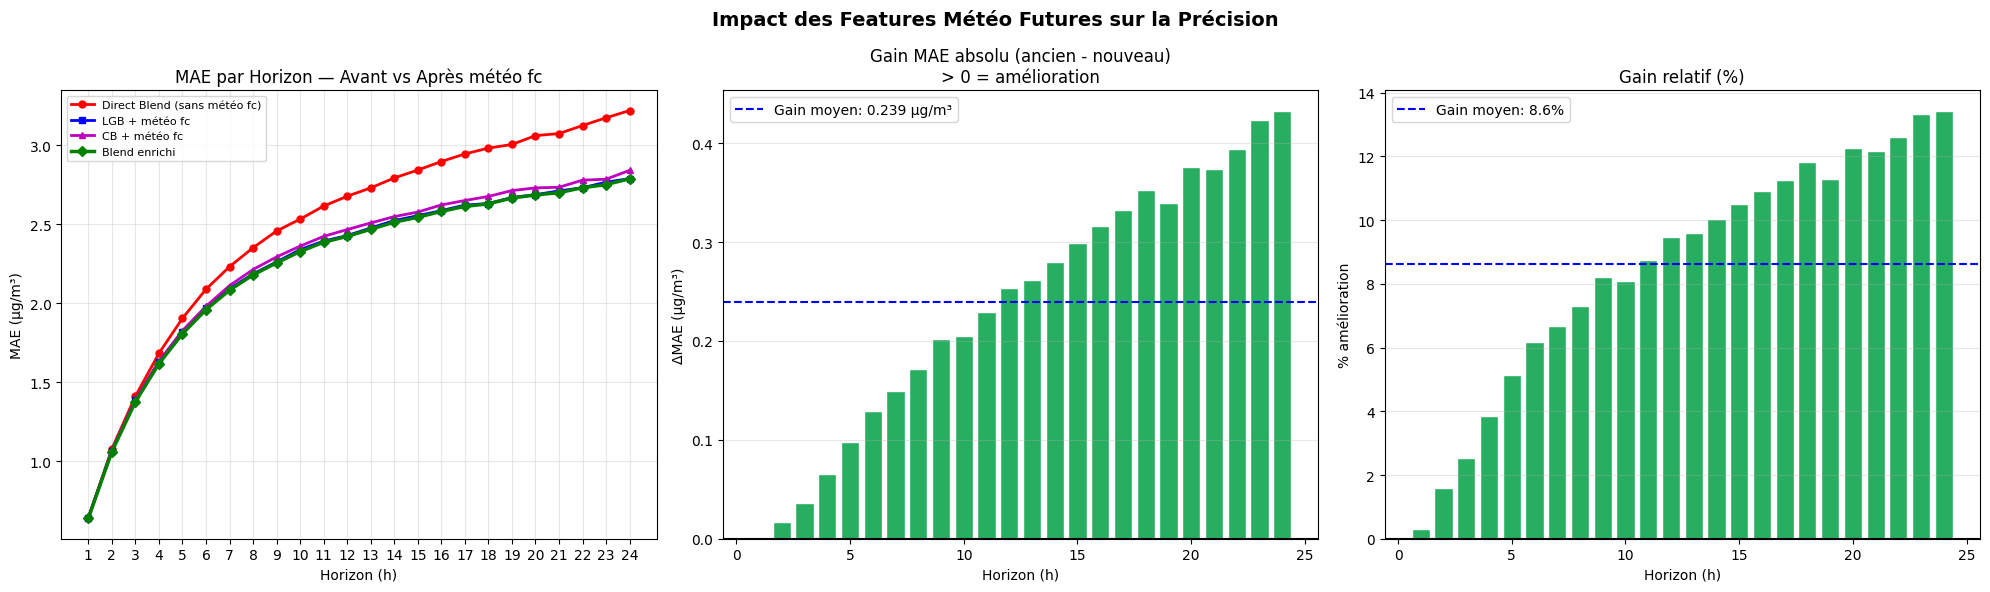


Résumé des gains :
  MAE moyen avant : 2.481
  MAE moyen après : 2.242
  Gain total      : 0.239 µg/m³ (8.6%)
  Gain H+12       : 0.254 µg/m³ (9.5%)
  Gain H+24       : 0.432 µg/m³ (13.4%)


In [33]:
# ── Visualisation comparaison ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. MAE par horizon
axes[0].plot(df_old['Horizon'],            df_old['MAE'],            'r-o', lw=2, label='Direct Blend (sans météo fc)', markersize=5)
axes[0].plot(df_lgb_enriched['Horizon'],   df_lgb_enriched['MAE'],   'b-s', lw=2, label='LGB + météo fc', markersize=5)
axes[0].plot(df_cb_enriched['Horizon'],    df_cb_enriched['MAE'],    'm-^', lw=2, label='CB + météo fc', markersize=5)
axes[0].plot(df_blend_enriched['Horizon'], df_blend_enriched['MAE'], 'g-D', lw=2.5, label='Blend enrichi', markersize=5)
axes[0].set(title='MAE par Horizon — Avant vs Après météo fc',
            xlabel='Horizon (h)', ylabel='MAE (µg/m³)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].set_xticks(HORIZONS)

# 2. Amélioration absolue (MAE ancien - MAE nouveau)
gain = (df_old.set_index('Horizon')['MAE'] - df_blend_enriched.set_index('Horizon')['MAE'])
colors = ['#27AE60' if v > 0 else '#E74C3C' for v in gain]
axes[1].bar(gain.index, gain.values, color=colors, edgecolor='white')
axes[1].axhline(0, color='black', lw=1.5)
axes[1].axhline(gain.mean(), color='blue', lw=1.5, linestyle='--',
                label=f'Gain moyen: {gain.mean():.3f} µg/m³')
axes[1].set(title='Gain MAE absolu (ancien - nouveau)\n> 0 = amélioration',
            xlabel='Horizon (h)', ylabel='ΔMAE (µg/m³)')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

# 3. Amélioration relative (%)
gain_pct = gain / df_old.set_index('Horizon')['MAE'] * 100
axes[2].bar(gain_pct.index, gain_pct.values,
            color=['#27AE60' if v > 0 else '#E74C3C' for v in gain_pct],
            edgecolor='white')
axes[2].axhline(0, color='black', lw=1.5)
axes[2].axhline(gain_pct.mean(), color='blue', lw=1.5, linestyle='--',
                label=f'Gain moyen: {gain_pct.mean():.1f}%')
axes[2].set(title='Gain relatif (%)',
            xlabel='Horizon (h)', ylabel='% amélioration')
axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Impact des Features Météo Futures sur la Précision', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'before_after_weather_fc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nRésumé des gains :')
print(f'  MAE moyen avant : {df_old["MAE"].mean():.3f}')
print(f'  MAE moyen après : {df_blend_enriched["MAE"].mean():.3f}')
print(f'  Gain total      : {gain.mean():.3f} µg/m³ ({gain_pct.mean():.1f}%)')
print(f'  Gain H+12       : {gain[12]:.3f} µg/m³ ({gain_pct[12]:.1f}%)')
print(f'  Gain H+24       : {gain[24]:.3f} µg/m³ ({gain_pct[24]:.1f}%)')

## 8. Feature Importance — Météo Future vs Passée

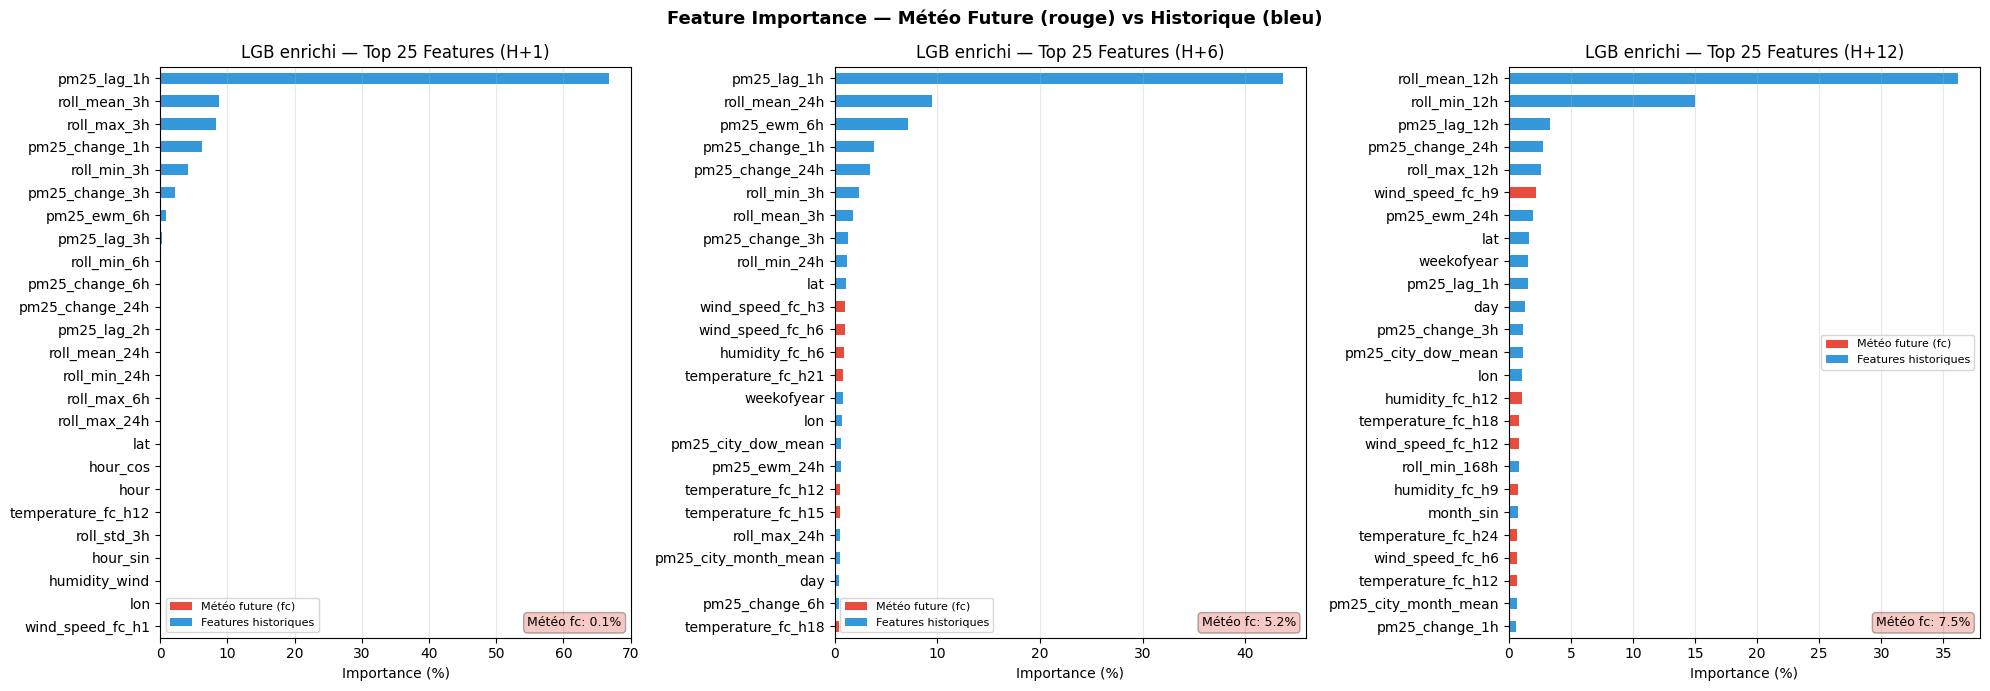

In [34]:
# ── Importance des features météo futures dans LGB H+12 ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, h, title in zip(
    axes,
    [1, 6, 12],
    ['H+1', 'H+6', 'H+12']
):
    fi = pd.Series(
        models_lgb_enriched[h].feature_importance(importance_type='gain'),
        index=FEAT_ENRICHED
    ).sort_values(ascending=False)

    fi_norm = (fi / fi.sum() * 100).head(25).sort_values()

    # Colorier différemment les features météo future
    colors = ['#E74C3C' if '_fc_h' in c else '#3498DB' for c in fi_norm.index]
    fi_norm.plot.barh(ax=ax, color=colors)

    # Légende
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E74C3C', label='Météo future (fc)'),
        Patch(facecolor='#3498DB', label='Features historiques')
    ]
    ax.legend(handles=legend_elements, fontsize=8)
    ax.set(title=f'LGB enrichi — Top 25 Features ({title})', xlabel='Importance (%)')
    ax.grid(axis='x', alpha=0.3)

    # Afficher le % total des features fc
    fc_importance = fi_norm[[c for c in fi_norm.index if '_fc_h' in c]].sum()
    ax.text(0.98, 0.02, f'Météo fc: {fc_importance:.1f}%',
            transform=ax.transAxes, ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='#E74C3C', alpha=0.3))

plt.suptitle('Feature Importance — Météo Future (rouge) vs Historique (bleu)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_importance_weather_fc.png', dpi=150, bbox_inches='tight')
plt.show()

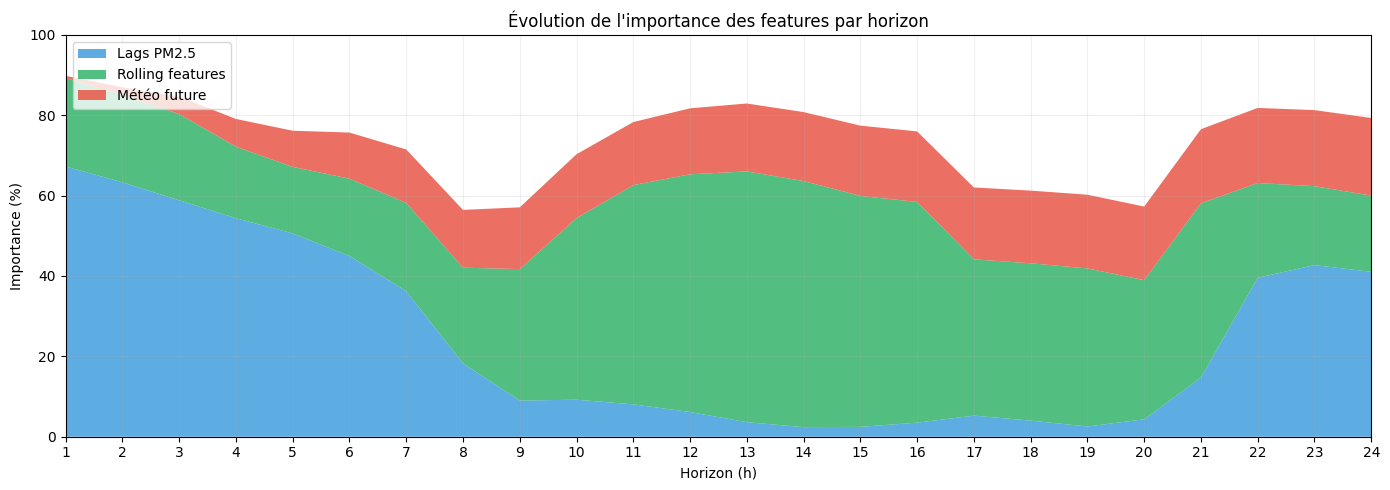


Importance météo future par horizon clé :
  H+ 1: Météo fc=0.5%  Lags=67.2%
  H+ 3: Météo fc=4.3%  Lags=58.8%
  H+ 6: Météo fc=11.5%  Lags=45.0%
  H+12: Météo fc=16.4%  Lags=6.1%
  H+18: Météo fc=18.1%  Lags=4.0%
  H+24: Météo fc=19.3%  Lags=41.0%


In [35]:
# ── Évolution de l'importance météo future par horizon ────────────────────────
fc_importance_by_h = []
for h in HORIZONS:
    fi = pd.Series(
        models_lgb_enriched[h].feature_importance(importance_type='gain'),
        index=FEAT_ENRICHED
    )
    total = fi.sum()
    fc_pct = fi[[c for c in fi.index if '_fc_h' in c]].sum() / total * 100
    lag_pct= fi[[c for c in fi.index if 'lag_' in c]].sum()  / total * 100
    roll_pct=fi[[c for c in fi.index if 'roll_' in c]].sum() / total * 100
    fc_importance_by_h.append({'Horizon': h, 'Météo fc (%)': fc_pct,
                                 'Lags PM2.5 (%)': lag_pct, 'Rolling (%)': roll_pct})

df_imp = pd.DataFrame(fc_importance_by_h)

fig, ax = plt.subplots(figsize=(14, 5))
ax.stackplot(
    df_imp['Horizon'],
    df_imp['Lags PM2.5 (%)'],
    df_imp['Rolling (%)'],
    df_imp['Météo fc (%)'],
    labels=['Lags PM2.5', 'Rolling features', 'Météo future'],
    colors=['#3498DB', '#27AE60', '#E74C3C'],
    alpha=0.8
)
ax.set(title='Évolution de l\'importance des features par horizon',
       xlabel='Horizon (h)', ylabel='Importance (%)',
       xlim=(1, 24), ylim=(0, 100))
ax.legend(loc='upper left'); ax.grid(alpha=0.2)
ax.set_xticks(HORIZONS)
plt.tight_layout()
plt.savefig(OUT_DIR / 'feature_importance_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nImportance météo future par horizon clé :')
for h in [1, 3, 6, 12, 18, 24]:
    row = df_imp[df_imp['Horizon'] == h].iloc[0]
    print(f'  H+{h:2d}: Météo fc={row["Météo fc (%)"]:.1f}%  Lags={row["Lags PM2.5 (%)"]:.1f}%')

## 9. Heatmap Finale

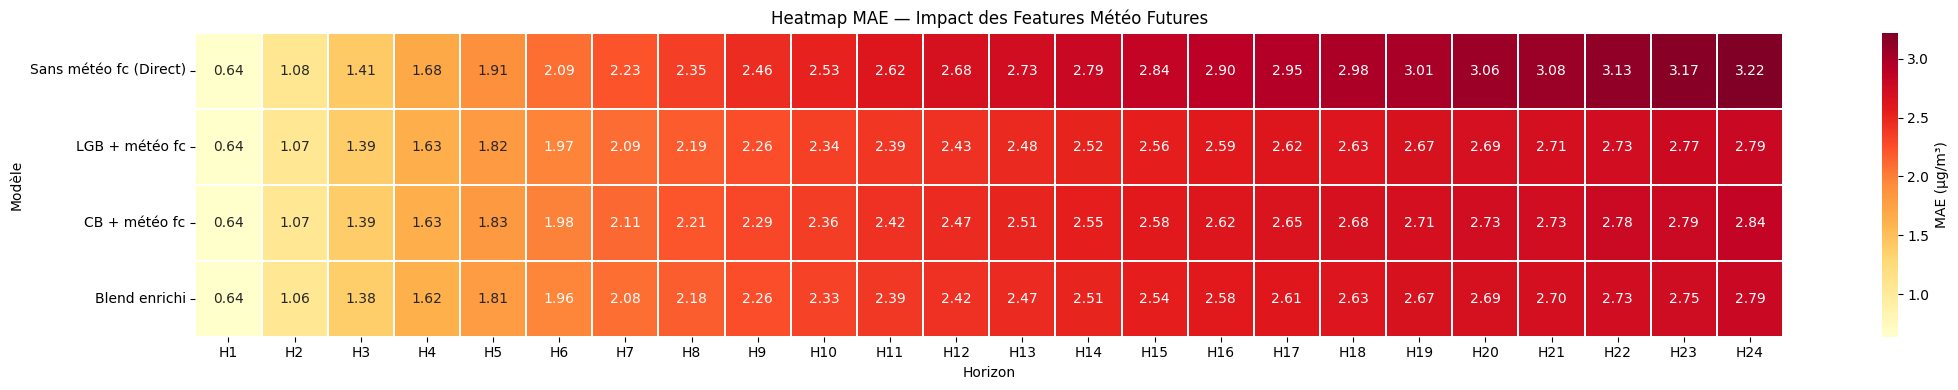

In [36]:
# ── Heatmap comparaison ───────────────────────────────────────────────────────
heat_data = pd.DataFrame({
    'Sans météo fc (Direct)':  df_old.set_index('Horizon')['MAE'],
    'LGB + météo fc':          df_lgb_enriched.set_index('Horizon')['MAE'],
    'CB + météo fc':           df_cb_enriched.set_index('Horizon')['MAE'],
    'Blend enrichi':           df_blend_enriched.set_index('Horizon')['MAE'],
}).T
heat_data.columns = [f'H{h}' for h in HORIZONS]

fig, ax = plt.subplots(figsize=(22, 4))
sns.heatmap(
    heat_data, annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.3, ax=ax,
    cbar_kws={'label': 'MAE (µg/m³)'}
)
ax.set(title='Heatmap MAE — Impact des Features Météo Futures',
       xlabel='Horizon', ylabel='Modèle')
plt.tight_layout()
plt.savefig(OUT_DIR / 'heatmap_weather_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Pipeline d'Inférence avec Prévisions Météo Réelles

In [37]:
class PM25PredictorV2:
    """
    Version 2 du predictor — utilise les prévisions météo OWM.
    """
    WEATHER_BASE = ['temperature', 'humidity', 'wind_speed', 'pressure', 'clouds']

    def __init__(self, models_lgb, models_cb, blend_weights,
                 feat_enriched, feat_cb_enriched, cat_feat_cb,
                 label_encoder, weather_horizons, api_key,
                 city_coords, cache_dir):
        self.models_lgb        = models_lgb
        self.models_cb         = models_cb
        self.blend_w           = blend_weights
        self.feat_enriched     = feat_enriched
        self.feat_cb_enriched  = feat_cb_enriched
        self.cat_feat_cb       = cat_feat_cb
        self.le                = label_encoder
        self.weather_horizons  = weather_horizons
        self.api_key           = api_key
        self.city_coords       = city_coords
        self.cache_dir         = cache_dir

    def _get_weather_forecast(self, city: str) -> pd.DataFrame:
        """Récupère les prévisions météo OWM pour une ville."""
        lat, lon = self.city_coords[city]
        return fetch_owm_forecast(city, lat, lon, self.api_key, self.cache_dir)

    def _interpolate_forecast(
        self, df_fc: pd.DataFrame, t_now: pd.Timestamp
    ) -> dict:
        """
        Interpole les prévisions OWM (toutes les 3h) vers chaque heure.
        Retourne un dict {horizon: {col: valeur}}
        """
        # OWM donne des données toutes les 3h — interpolation linéaire
        df_fc = df_fc.copy().sort_values('datetime')
        df_fc = df_fc.set_index('datetime')

        # Réindexer sur chaque heure
        hourly_idx = pd.date_range(
            t_now + pd.Timedelta(hours=1),
            t_now + pd.Timedelta(hours=24),
            freq='h'
        )
        df_hourly = df_fc[['temp_fc','humidity_fc','wind_speed_fc',
                            'pressure_fc','clouds_fc']]
        df_hourly = df_hourly.reindex(
            df_hourly.index.union(hourly_idx)
        ).interpolate(method='time').loc[hourly_idx]

        # Mapper sur les noms de features
        name_map = {
            'temp_fc':       'temperature',
            'humidity_fc':   'humidity',
            'wind_speed_fc': 'wind_speed',
            'pressure_fc':   'pressure',
            'clouds_fc':     'clouds',
        }
        result = {}
        for h in self.weather_horizons:
            t_h = t_now + pd.Timedelta(hours=h)
            if t_h in df_hourly.index:
                row = df_hourly.loc[t_h]
                result[h] = {name_map[k]: float(row[k]) for k in name_map}
        return result

    def predict(
        self, city: str, t_now: pd.Timestamp,
        historical_df: pd.DataFrame,
        use_api: bool = True
    ) -> pd.DataFrame:
        """
        Prédiction H+1 → H+24 avec prévisions météo.
        use_api=False → utilise les vraies valeurs historiques (test/debug)
        """
        # ── Construire la ligne de base ────────────────────────────────────────
        city_hist = historical_df[
            (historical_df['city'] == city) &
            (historical_df['datetime'] <= t_now)
        ].sort_values('datetime').tail(336)

        if len(city_hist) < 24:
            raise ValueError(f'Historique insuffisant pour {city}')

        # Features météo futures
        if use_api and self.api_key != 'VOTRE_CLE_API_ICI':
            df_fc = self._get_weather_forecast(city)
            fc_values = self._interpolate_forecast(df_fc, t_now)
        else:
            # Mode debug : utiliser les vraies valeurs futures
            fc_values = {}
            for h in self.weather_horizons:
                t_h = t_now + pd.Timedelta(hours=h)
                row_h = historical_df[
                    (historical_df['city'] == city) &
                    (historical_df['datetime'] == t_h)
                ]
                if len(row_h) > 0:
                    fc_values[h] = {
                        'temperature': float(row_h['temperature'].iloc[0]),
                        'humidity':    float(row_h['humidity'].iloc[0]),
                        'wind_speed':  float(row_h['wind_speed'].iloc[0]),
                        'pressure':    float(row_h['pressure'].iloc[0]),
                        'clouds':      float(row_h['clouds'].iloc[0]),
                    }

        # ── Construire le vecteur de features ─────────────────────────────────
        # (même logique que PM25Predictor v1 + ajout des features fc)
        last = city_hist.iloc[-1]
        pm25_series = city_hist.set_index('datetime')['pm2_5']
        pm25_vals   = pm25_series.values

        row = {}
        row['city']       = city
        row['city_enc']   = self.le.transform([city])[0] if city in self.le.classes_ else -1
        row['lat']        = float(last['lat'])
        row['lon']        = float(last['lon'])
        row['hour']       = t_now.hour
        row['dayofweek']  = t_now.dayofweek
        row['month']      = t_now.month
        row['day']        = t_now.day
        row['weekofyear'] = t_now.isocalendar()[1]
        row['hour_sin']   = np.sin(2*np.pi*t_now.hour/24)
        row['hour_cos']   = np.cos(2*np.pi*t_now.hour/24)
        row['dow_sin']    = np.sin(2*np.pi*t_now.dayofweek/7)
        row['dow_cos']    = np.cos(2*np.pi*t_now.dayofweek/7)
        row['month_sin']  = np.sin(2*np.pi*t_now.month/12)
        row['month_cos']  = np.cos(2*np.pi*t_now.month/12)

        for lag in [1,2,3,6,12,24,48,72,168,336]:
            lag_dt = t_now - pd.Timedelta(hours=lag)
            row[f'pm25_lag_{lag}h'] = float(pm25_series.get(lag_dt, np.nan))

        for w in [3,6,12,24,48,72,168]:
            sl = pm25_vals[-w:] if len(pm25_vals)>=w else pm25_vals
            row[f'roll_mean_{w}h'] = float(np.nanmean(sl))
            row[f'roll_std_{w}h']  = float(np.nanstd(sl))
            row[f'roll_min_{w}h']  = float(np.nanmin(sl))
            row[f'roll_max_{w}h']  = float(np.nanmax(sl))

        row['pm25_change_1h']  = float(pm25_vals[-1] - pm25_vals[-2])  if len(pm25_vals)>=2 else np.nan
        row['pm25_change_3h']  = float(pm25_vals[-1] - row['pm25_lag_3h'])  if not np.isnan(row.get('pm25_lag_3h',np.nan)) else np.nan
        row['pm25_change_6h']  = float(pm25_vals[-1] - row['pm25_lag_6h'])  if not np.isnan(row.get('pm25_lag_6h',np.nan)) else np.nan
        row['pm25_change_24h'] = float(pm25_vals[-1] - row['pm25_lag_24h']) if not np.isnan(row.get('pm25_lag_24h',np.nan)) else np.nan
        ewm6  = float(pd.Series(pm25_vals.astype(float)).ewm(span=6).mean().iloc[-1])  if len(pm25_vals)>0 else np.nan
        ewm24 = float(pd.Series(pm25_vals.astype(float)).ewm(span=24).mean().iloc[-1]) if len(pm25_vals)>0 else np.nan
        row['pm25_ewm_6h']  = ewm6
        row['pm25_ewm_24h'] = ewm24
        row['temp_change_1h']     = float(city_hist['temperature'].diff().iloc[-1]) if 'temperature' in city_hist else np.nan
        row['humidity_change_1h'] = float(city_hist['humidity'].diff().iloc[-1])    if 'humidity' in city_hist else np.nan
        row['temp_humidity'] = float(last['temperature']) * float(last['humidity'])
        row['temp_wind']     = float(last['temperature']) * float(last['wind_speed'])
        row['humidity_wind'] = float(last['humidity'])    * float(last['wind_speed'])
        row['pm25_city_hour_mean'] = float(pm25_series[pm25_series.index.hour==t_now.hour].mean())
        row['pm25_city_dow_mean']  = float(pm25_series[pm25_series.index.dayofweek==t_now.dayofweek].mean())
        row['pm25_city_month_mean']= float(pm25_series[pm25_series.index.month==t_now.month].mean())

        # Ajouter les features météo futures
        for h_fc, vals in fc_values.items():
            for wc in self.WEATHER_BASE:
                row[f'{wc}_fc_h{h_fc}'] = vals.get(wc, np.nan)

        row_df = pd.DataFrame([row])

        # ── Prédiction pour chaque horizon ────────────────────────────────────
        preds = {}
        for h in range(1, 25):
            x_lgb = row_df[self.feat_enriched].fillna(0).values.astype(np.float32)
            p_lgb = self.models_lgb[h].predict(x_lgb)[0]

            pool  = Pool(row_df[self.feat_cb_enriched].fillna(0),
                         cat_features=self.cat_feat_cb)
            p_cb  = self.models_cb[h].predict(pool)[0]

            p = max(0.0, self.blend_w[0]*p_lgb + self.blend_w[1]*p_cb)
            preds[h] = round(float(p), 2)

        return pd.DataFrame({
            'datetime':  [t_now + pd.Timedelta(hours=h) for h in range(1,25)],
            'horizon':   [f'H+{h}' for h in range(1,25)],
            'pm25_pred': list(preds.values()),
            'city':      city,
        })


# ── Instancier V2 ─────────────────────────────────────────────────────────────
predictor_v2 = PM25PredictorV2(
    models_lgb        = models_lgb_enriched,
    models_cb         = models_cb_enriched,
    blend_weights     = opt_w_new,
    feat_enriched     = FEAT_ENRICHED,
    feat_cb_enriched  = FEAT_CB_ENRICHED,
    cat_feat_cb       = CAT_FEAT_CB,
    label_encoder     = le,
    weather_horizons  = WEATHER_HORIZONS,
    api_key           = OWM_API_KEY,
    city_coords       = CITY_COORDS,
    cache_dir         = WEATHER_DIR,
)
print('✅ PM25PredictorV2 instancié')

✅ PM25PredictorV2 instancié


🔮 Inférence V2 pour Casablanca à T = 2026-06-07 22:00:00


,datetime,horizon,pm25_pred,city
0,2026-06-07 23:00:00,H+1,15.6100,Casablanca
1,2026-06-08 00:00:00,H+2,16.1200,Casablanca
2,2026-06-08 01:00:00,H+3,16.2700,Casablanca
3,2026-06-08 02:00:00,H+4,16.6600,Casablanca
4,2026-06-08 03:00:00,H+5,16.7200,Casablanca
5,2026-06-08 04:00:00,H+6,16.3200,Casablanca
6,2026-06-08 05:00:00,H+7,16.4200,Casablanca
7,2026-06-08 06:00:00,H+8,16.1900,Casablanca
8,2026-06-08 07:00:00,H+9,16.0200,Casablanca
9,2026-06-08 08:00:00,H+10,16.1400,Casablanca



MAE V2 inférence : 3.040 µg/m³


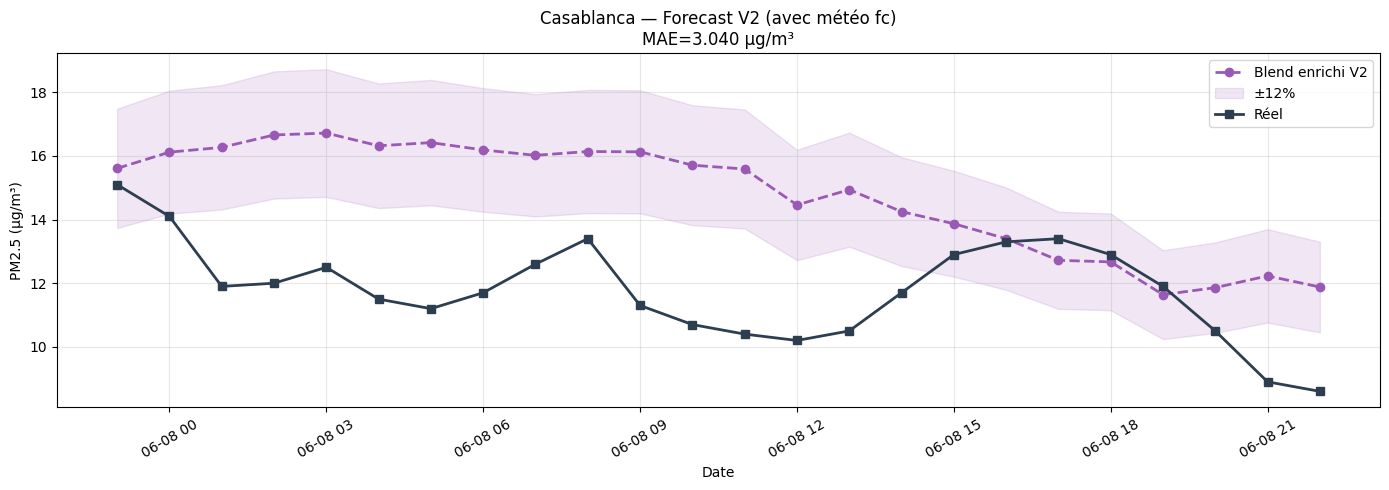

In [38]:
# ── Test inférence V2 ─────────────────────────────────────────────────────────
CITY_TEST = 'Casablanca'
T_TEST    = df_test[df_test['city']==CITY_TEST]['datetime'].max() - pd.Timedelta(hours=24)

print(f'🔮 Inférence V2 pour {CITY_TEST} à T = {T_TEST}')
forecast_v2 = predictor_v2.predict(
    CITY_TEST, T_TEST, df_enriched, use_api=False  # use_api=True en production
)
display(forecast_v2)

# Comparer avec vérité terrain
gt = df_test[
    (df_test['city']==CITY_TEST) &
    (df_test['datetime'] > T_TEST) &
    (df_test['datetime'] <= T_TEST + pd.Timedelta(hours=24))
][['datetime','pm2_5']].sort_values('datetime')

if len(gt) > 0:
    merged = forecast_v2.merge(gt.rename(columns={'pm2_5':'pm25_real'}), on='datetime', how='left')
    valid  = merged.dropna(subset=['pm25_real'])
    mae_v2 = mean_absolute_error(valid['pm25_real'], valid['pm25_pred'])
    print(f'\nMAE V2 inférence : {mae_v2:.3f} µg/m³')

    fig, ax = plt.subplots(figsize=(14,5))
    ax.plot(forecast_v2['datetime'], forecast_v2['pm25_pred'],
            'o--', color='#9B59B6', lw=2, markersize=6, label='Blend enrichi V2')
    ax.fill_between(forecast_v2['datetime'],
                    forecast_v2['pm25_pred']*0.88, forecast_v2['pm25_pred']*1.12,
                    alpha=0.15, color='#9B59B6', label='±12%')
    ax.plot(gt['datetime'], gt['pm2_5'], 's-', color='#2C3E50', lw=2, label='Réel')
    ax.set(title=f'{CITY_TEST} — Forecast V2 (avec météo fc)\nMAE={mae_v2:.3f} µg/m³',
           xlabel='Date', ylabel='PM2.5 (µg/m³)')
    ax.legend(); ax.grid(alpha=0.3)
    plt.xticks(rotation=30); plt.tight_layout()
    plt.savefig(OUT_DIR / f'inference_v2_{CITY_TEST.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

🔮 TEST INFÉRENCE 24H ALÉATOIRE
Ville : Casablanca
Start : 2026-03-27 04:00:00
End   : 2026-03-28 04:00:00

📊 MÉTRIQUES
MAE  : 5.297
RMSE : 6.257
R²   : 0.575


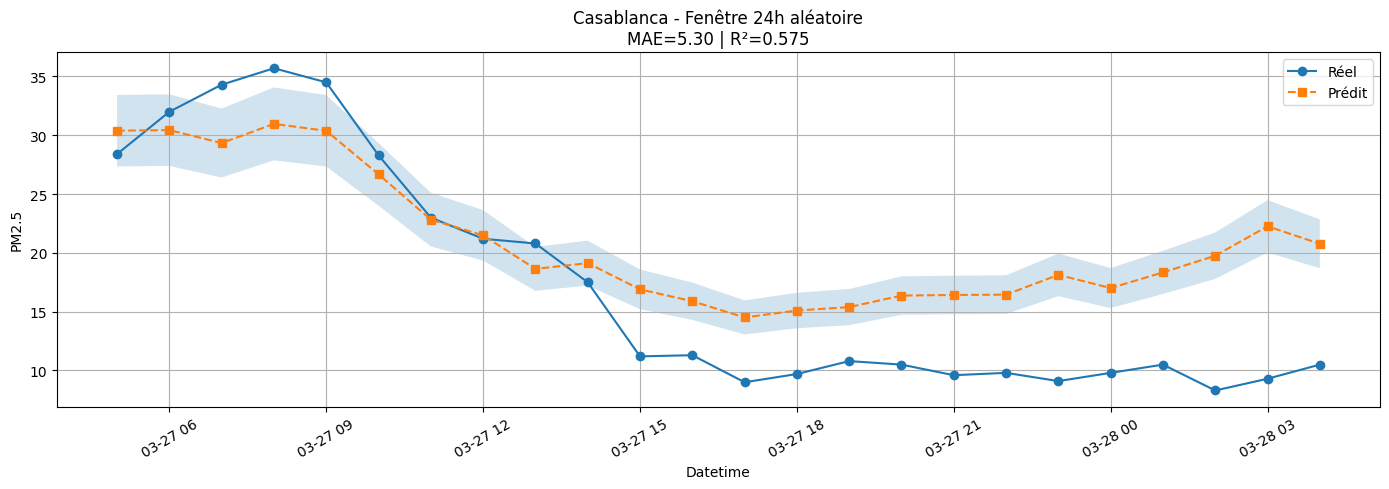

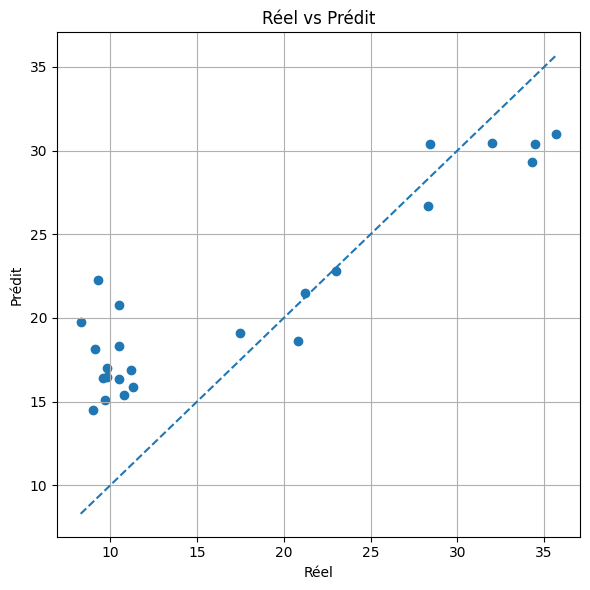

In [ ]:
# ════════════════════════════════════════════════════════════════
# TEST INFÉRENCE : FENÊTRE ALÉATOIRE 24H (ROBUSTE)
# ════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ----------------------------------------------------------------
# PARAMÈTRES
# ----------------------------------------------------------------
CITY_TEST = "Casablanca"

df_city = df_test[df_test["city"] == CITY_TEST].sort_values("datetime").copy()

# ----------------------------------------------------------------
# Construire des fenêtres valides (rolling 24h)
# ----------------------------------------------------------------
all_times = df_city["datetime"].values

valid_start_times = []

for i in range(len(df_city)):
    t = df_city.iloc[i]["datetime"]

    window = df_city[
        (df_city["datetime"] > t) &
        (df_city["datetime"] <= t + pd.Timedelta(hours=24))
    ]

    if len(window) == 24:   # on veut exactement 24 points horaires
        valid_start_times.append(t)

if len(valid_start_times) == 0:
    raise ValueError("Aucune fenêtre 24h valide trouvée dans le dataset.")

# ----------------------------------------------------------------
# Choix aléatoire d'une fenêtre valide
# ----------------------------------------------------------------
T_TEST = np.random.choice(valid_start_times)
T_TEST = pd.Timestamp(T_TEST)

print("🔮 TEST INFÉRENCE 24H ALÉATOIRE")
print("Ville :", CITY_TEST)
print("Start :", T_TEST)
print("End   :", T_TEST + pd.Timedelta(hours=24))

# ----------------------------------------------------------------
# INFÉRENCE
# ----------------------------------------------------------------
forecast_v2 = predictor_v2.predict(
    CITY_TEST,
    T_TEST,
    df_enriched,
    use_api=False
)

# ----------------------------------------------------------------
# VÉRITÉ TERRAIN
# ----------------------------------------------------------------
gt = df_city[
    (df_city["datetime"] > T_TEST) &
    (df_city["datetime"] <= T_TEST + pd.Timedelta(hours=24))
][["datetime", "pm2_5"]]

# ----------------------------------------------------------------
# MERGE
# ----------------------------------------------------------------
merged = forecast_v2.merge(
    gt.rename(columns={"pm2_5": "pm25_real"}),
    on="datetime",
    how="left"
)

valid = merged.dropna()

# ----------------------------------------------------------------
# MÉTRIQUES
# ----------------------------------------------------------------
mae = mean_absolute_error(valid["pm25_real"], valid["pm25_pred"])
rmse = np.sqrt(mean_squared_error(valid["pm25_real"], valid["pm25_pred"]))
r2 = r2_score(valid["pm25_real"], valid["pm25_pred"])

print("\n📊 MÉTRIQUES")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

# ----------------------------------------------------------------
# PLOT 1 : time series
# ----------------------------------------------------------------
plt.figure(figsize=(14,5))

plt.plot(valid["datetime"], valid["pm25_real"], "o-", label="Réel")
plt.plot(valid["datetime"], valid["pm25_pred"], "s--", label="Prédit")

plt.fill_between(
    valid["datetime"],
    valid["pm25_pred"] * 0.9,
    valid["pm25_pred"] * 1.1,
    alpha=0.2
)

plt.title(f"{CITY_TEST} - Fenêtre 24h aléatoire\nMAE={mae:.2f} | R²={r2:.3f}")
plt.xlabel("Datetime")
plt.ylabel("PM2.5")
plt.grid()
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# ----------------------------------------------------------------
# PLOT 2 : scatter réel vs prédit
# ----------------------------------------------------------------
plt.figure(figsize=(6,6))

plt.scatter(valid["pm25_real"], valid["pm25_pred"])

min_v = min(valid["pm25_real"].min(), valid["pm25_pred"].min())
max_v = max(valid["pm25_real"].max(), valid["pm25_pred"].max())

plt.plot([min_v, max_v], [min_v, max_v], "--")

plt.xlabel("Réel")
plt.ylabel("Prédit")
plt.title("Réel vs Prédit")
plt.grid()
plt.tight_layout()
plt.show()

### BACKTEST MULTI-VILLES + MULTI-FENÊTRES (24H)

,city,start_time,mae,rmse,r2
0,Agadir,2026-04-21 19:00:00,2.7975,3.1754,-0.4234
1,Agadir,2026-05-06 18:00:00,0.3675,0.6090,0.6904
2,Agadir,2026-02-28 02:00:00,3.7196,4.7518,-4.1043
3,Agadir,2026-05-31 16:00:00,2.3212,2.5206,-0.2200
4,Agadir,2026-05-28 21:00:00,0.7846,1.1199,0.7195



📊 SCORE GLOBAL
MAE moyen : 2.0677600000000003
RMSE moyen: 2.467748172929298
R² moyen  : -1.5172087365120437


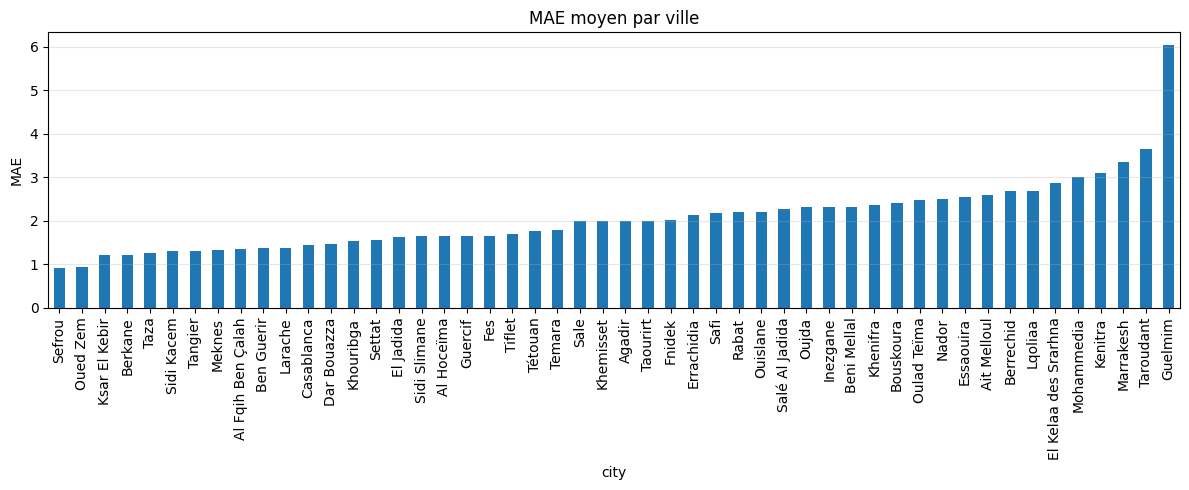

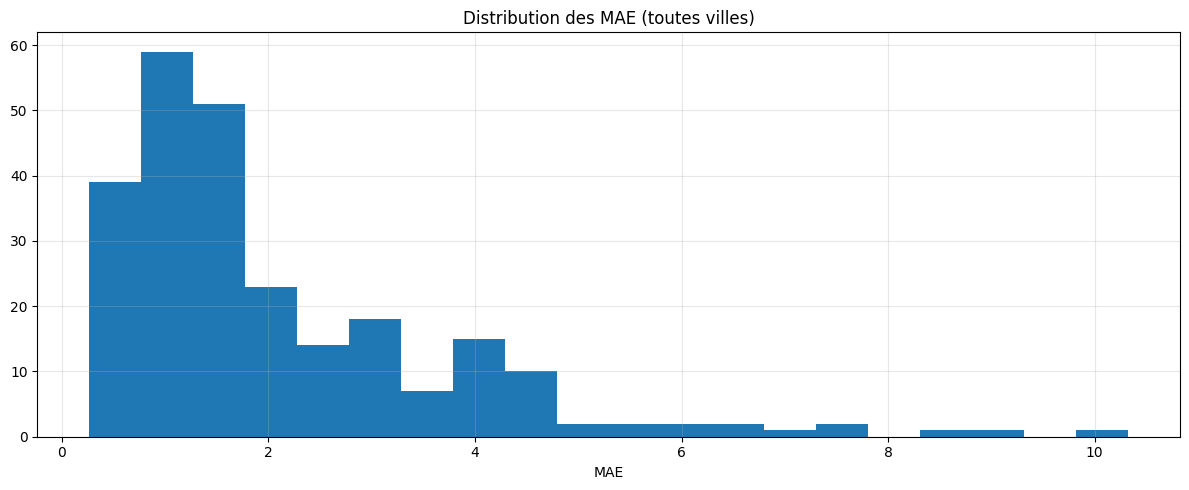

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ═══════════════════════════════════════════════════════
# PARAMÈTRES
# ═══════════════════════════════════════════════════════
CITIES = df_test["city"].unique()
N_WINDOWS_PER_CITY = 5   #  nombre de fenêtres testées par ville

results = []

# ═══════════════════════════════════════════════════════
# LOOP SUR VILLES
# ═══════════════════════════════════════════════════════
for CITY_TEST in CITIES:

    df_city = df_test[df_test["city"] == CITY_TEST].sort_values("datetime").copy()

    valid_start_times = []

    # ---------------------------------------------------
    # construction des fenêtres valides 24h
    # ---------------------------------------------------
    for i in range(len(df_city)):
        t = df_city.iloc[i]["datetime"]

        window = df_city[
            (df_city["datetime"] > t) &
            (df_city["datetime"] <= t + pd.Timedelta(hours=24))
        ]

        if len(window) == 24:
            valid_start_times.append(t)

    if len(valid_start_times) == 0:
        print(f"⚠️ Pas de fenêtres valides pour {CITY_TEST}")
        continue

    # tirer plusieurs fenêtres
    sampled_times = np.random.choice(
        valid_start_times,
        size=min(N_WINDOWS_PER_CITY, len(valid_start_times)),
        replace=False
    )

    # ═══════════════════════════════════════════════
    # LOOP SUR FENÊTRES
    # ═══════════════════════════════════════════════
    for T_TEST in sampled_times:

        T_TEST = pd.Timestamp(T_TEST)

        forecast_v2 = predictor_v2.predict(
            CITY_TEST,
            T_TEST,
            df_enriched,
            use_api=False
        )

        gt = df_city[
            (df_city["datetime"] > T_TEST) &
            (df_city["datetime"] <= T_TEST + pd.Timedelta(hours=24))
        ][["datetime", "pm2_5"]]

        merged = forecast_v2.merge(
            gt.rename(columns={"pm2_5": "pm25_real"}),
            on="datetime",
            how="inner"
        )

        if len(merged) == 0:
            continue

        mae = mean_absolute_error(merged["pm25_real"], merged["pm25_pred"])
        rmse = np.sqrt(mean_squared_error(merged["pm25_real"], merged["pm25_pred"]))

        # R² peut échouer si variance faible
        try:
            r2 = r2_score(merged["pm25_real"], merged["pm25_pred"])
        except:
            r2 = np.nan

        results.append({
            "city": CITY_TEST,
            "start_time": T_TEST,
            "mae": mae,
            "rmse": rmse,
            "r2": r2
        })

# ═══════════════════════════════════════════════════════
# DATAFRAME FINAL
# ═══════════════════════════════════════════════════════
results_df = pd.DataFrame(results)

display(results_df.head())

print("\n📊 SCORE GLOBAL")
print("=" * 40)
print("MAE moyen :", results_df["mae"].mean())
print("RMSE moyen:", results_df["rmse"].mean())
print("R² moyen  :", results_df["r2"].mean())

# ═══════════════════════════════════════════════════════
# VISUALISATION
# ═══════════════════════════════════════════════════════

plt.figure(figsize=(12,5))
results_df.groupby("city")["mae"].mean().sort_values().plot(kind="bar")
plt.title("MAE moyen par ville")
plt.ylabel("MAE")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))
results_df["mae"].hist(bins=20)
plt.title("Distribution des MAE (toutes villes)")
plt.xlabel("MAE")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Sauvegarde

In [41]:
# ── Sauvegarder les modèles enrichis ──────────────────────────────────────────
lgb_e_dir = OUT_DIR / 'models_lgb_enriched'
cb_e_dir  = OUT_DIR / 'models_cb_enriched'
lgb_e_dir.mkdir(exist_ok=True)
cb_e_dir.mkdir(exist_ok=True)

for h in HORIZONS:
    models_lgb_enriched[h].save_model(str(lgb_e_dir / f'lgb_enriched_h{h}.txt'))
    models_cb_enriched[h].save_model(str(cb_e_dir  / f'cb_enriched_h{h}.cbm'))

# Sauvegarder les métadonnées
joblib.dump(le, OUT_DIR / 'label_encoder_v2.pkl')
np.save(OUT_DIR / 'blend_weights_v2.npy', opt_w_new)

with open(OUT_DIR / 'feat_enriched.json', 'w') as f:
    json.dump(FEAT_ENRICHED, f)
with open(OUT_DIR / 'feat_cb_enriched.json', 'w') as f:
    json.dump(FEAT_CB_ENRICHED, f)
with open(OUT_DIR / 'weather_horizons.json', 'w') as f:
    json.dump(WEATHER_HORIZONS, f)

print(f'✅ {len(HORIZONS)*2} modèles sauvegardés dans {OUT_DIR}')

# ── Résumé final ──────────────────────────────────────────────────────────────
print('\n' + '═'*65)
print('  🏆  RÉSUMÉ FINAL V2')
print('═'*65)

final = pd.DataFrame({
    'Modèle': ['Direct Blend V1', 'Blend Enrichi V2'],
    'MAE_mean':  [df_old['MAE'].mean().round(3),            df_blend_enriched['MAE'].mean().round(3)],
    'MAE_H1':   [df_old[df_old['Horizon']==1]['MAE'].values[0],   df_blend_enriched[df_blend_enriched['Horizon']==1]['MAE'].values[0]],
    'MAE_H6':   [df_old[df_old['Horizon']==6]['MAE'].values[0],   df_blend_enriched[df_blend_enriched['Horizon']==6]['MAE'].values[0]],
    'MAE_H12':  [df_old[df_old['Horizon']==12]['MAE'].values[0],  df_blend_enriched[df_blend_enriched['Horizon']==12]['MAE'].values[0]],
    'MAE_H24':  [df_old[df_old['Horizon']==24]['MAE'].values[0],  df_blend_enriched[df_blend_enriched['Horizon']==24]['MAE'].values[0]],
})

display(final.style.background_gradient(
    subset=['MAE_mean','MAE_H1','MAE_H6','MAE_H12','MAE_H24'], cmap='RdYlGn_r'
))

print(f'\n→ Gain moyen : {(df_old["MAE"].mean() - df_blend_enriched["MAE"].mean()):.3f} µg/m³')
print(f'→ Gain H+12  : {(df_old[df_old["Horizon"]==12]["MAE"].values[0] - df_blend_enriched[df_blend_enriched["Horizon"]==12]["MAE"].values[0]):.3f} µg/m³')
print(f'→ Gain H+24  : {(df_old[df_old["Horizon"]==24]["MAE"].values[0] - df_blend_enriched[df_blend_enriched["Horizon"]==24]["MAE"].values[0]):.3f} µg/m³')
print(f'\n🔮 Predictor V2 prêt → predictor_v2.predict(city, datetime, df, use_api=True)')
final.to_csv(OUT_DIR / 'final_summary_v2.csv', index=False)

✅ 48 modèles sauvegardés dans E:\pipeline\test2\weather_model_outputs

═════════════════════════════════════════════════════════════════
  🏆  RÉSUMÉ FINAL V2
═════════════════════════════════════════════════════════════════


,Modèle,MAE_mean,MAE_H1,MAE_H6,MAE_H12,MAE_H24
0,Direct Blend V1,2.481000,0.640000,2.089000,2.678000,3.221000
1,Blend Enrichi V2,2.242000,0.638000,1.960000,2.424000,2.789000



→ Gain moyen : 0.239 µg/m³
→ Gain H+12  : 0.254 µg/m³
→ Gain H+24  : 0.432 µg/m³

🔮 Predictor V2 prêt → predictor_v2.predict(city, datetime, df, use_api=True)
